# Training Model YOLOv8 Instance Segmentation (yolov8n-seg)

Notebook ini melatih model **YOLOv8 Instance Segmentation** menggunakan GPU **NVIDIA RTX 2050** pada dataset poligon terbaru (`dataset_tambahan`).

### Fitur Utama:
- **Model**: `yolov8n-seg.pt` (Mendeteksi objek dengan arsiran poligon presisi tinggi).
- **Dataset**: `dataset_tambahan` (52 gambar poligon).
- **Logika Safety**: Mendeteksi kondisi `danger` (kendaraan terjebak/palang bermasalah) vs `safe`.
- **Train-Val Split**: 80% Latih (41 gambar), 20% Validasi (11 gambar) secara otomatis.

In [1]:
# 1. Verifikasi PyTorch CUDA dan GPU NVIDIA RTX 2050
import torch

print("=" * 60)
print(f"Versi PyTorch       : {torch.__version__}")
cuda_status = torch.cuda.is_available()
print(f"CUDA (GPU) Tersedia : {cuda_status}")

if cuda_status:
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"Nama GPU            : {gpu_name}")
    print(f"Total VRAM          : {vram_gb:.2f} GB")
    target_device = 0
    torch.cuda.empty_cache()
else:
    print("Peringatan: GPU tidak aktif. Gunakan CPU.")
    target_device = 'cpu'

print("=" * 60)

Versi PyTorch       : 2.6.0+cu124
CUDA (GPU) Tersedia : True
Nama GPU            : NVIDIA GeForce RTX 2050
Total VRAM          : 4.00 GB


In [2]:
# 2. Persiapan Dataset dataset_tambahan & Auto Train-Val Split (80:20)
import os
import shutil
import random
import glob

source_dataset_dir = os.path.abspath('datasets/dataset_tambahan' if os.path.exists('datasets/dataset_tambahan') else 'dataset_tambahan')
active_dataset_dir = os.path.abspath('datasets/seg_dataset' if os.path.exists('datasets/seg_dataset') else 'seg_dataset')

# Buat folder kerja baru untuk segmentasi agar dataset asli tetap aman
if os.path.exists(active_dataset_dir):
    shutil.rmtree(active_dataset_dir)
os.makedirs(active_dataset_dir, exist_ok=True)

train_img_dest = os.path.join(active_dataset_dir, 'train', 'images')
train_lbl_dest = os.path.join(active_dataset_dir, 'train', 'labels')
val_img_dest = os.path.join(active_dataset_dir, 'valid', 'images')
val_lbl_dest = os.path.join(active_dataset_dir, 'valid', 'labels')

for p in [train_img_dest, train_lbl_dest, val_img_dest, val_lbl_dest]:
    os.makedirs(p, exist_ok=True)

# Ambil semua gambar dari folder dataset_tambahan/train/images
src_train_imgs = glob.glob(os.path.join(source_dataset_dir, 'train', 'images', '*.*'))
src_train_lbls = os.path.join(source_dataset_dir, 'train', 'labels')

print(f"Total gambar ditemukan di dataset_tambahan: {len(src_train_imgs)}")

# Acak secara teratur (reproducible)
random.seed(42)
shuffled_imgs = list(src_train_imgs)
random.shuffle(shuffled_imgs)

# 80% Train, 20% Valid
split_idx = int(len(shuffled_imgs) * 0.80)
train_files = shuffled_imgs[:split_idx]
val_files = shuffled_imgs[split_idx:]

def copy_pairs(files, dest_img_dir, dest_lbl_dir):
    for img_path in files:
        shutil.copy(img_path, os.path.join(dest_img_dir, os.path.basename(img_path)))
        base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_file = os.path.join(src_train_lbls, base + '.txt')
        if os.path.exists(lbl_file):
            shutil.copy(lbl_file, os.path.join(dest_lbl_dir, os.path.basename(lbl_file)))

copy_pairs(train_files, train_img_dest, train_lbl_dest)
copy_pairs(val_files, val_img_dest, val_lbl_dest)

print(f"[SUKSES] Pembagian Dataset:")
print(f"  - Training Set   : {len(train_files)} gambar")
print(f"  - Validation Set : {len(val_files)} gambar")

# Tulis file data.yaml untuk Segmentation
yaml_path = os.path.join(active_dataset_dir, 'data.yaml')
formatted_path = active_dataset_dir.replace('\\', '/')

yaml_content = f"""
path: {formatted_path}
train: train/images
val: valid/images

nc: 2
names: ['danger', 'safe']
"""

with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print(f"File data.yaml siap di: {yaml_path}")

Total gambar ditemukan di dataset_tambahan: 52
[SUKSES] Pembagian Dataset:
  - Training Set   : 41 gambar
  - Validation Set : 11 gambar
File data.yaml siap di: c:\Users\Pongo\train-detector\seg_dataset\data.yaml


In [3]:
# 3. Training YOLOv8n Segmentation di NVIDIA RTX 2050
from ultralytics import YOLO
import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Load model dasar YOLOv8 Segmentation
model = YOLO('yolov8n-seg.pt')

# Jalankan training 60 epochs
results = model.train(
    data=yaml_path,
    epochs=60,                # 60 epochs sangat optimal untuk segmentasi dataset ini
    imgsz=640,
    batch=8,
    project='runs/segment',
    name='railway_seg_rtx2050',
    device=target_device,
    plots=True
)

save_dir = results.save_dir
print("Training Segmentasi Selesai!")
print(f"Hasil tersimpan di: {save_dir}")

Ultralytics 8.4.173  Python-3.12.6 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Pongo\train-detector\seg_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=railway_seg_rtx2050, nb

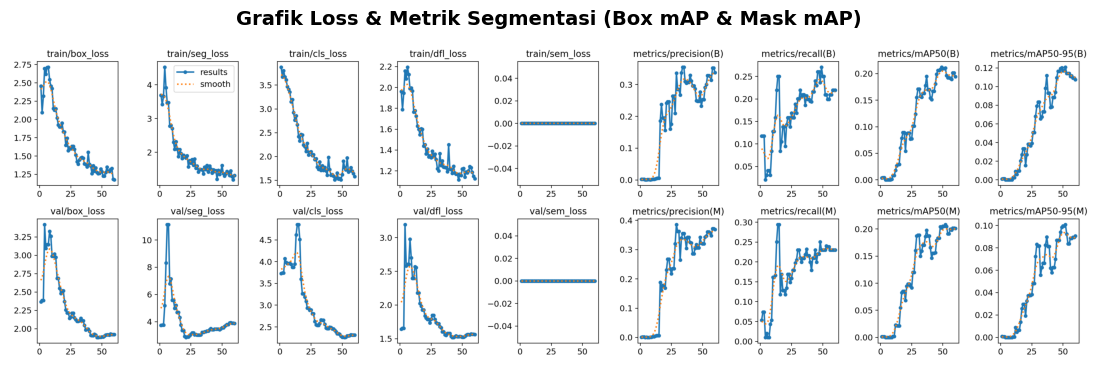

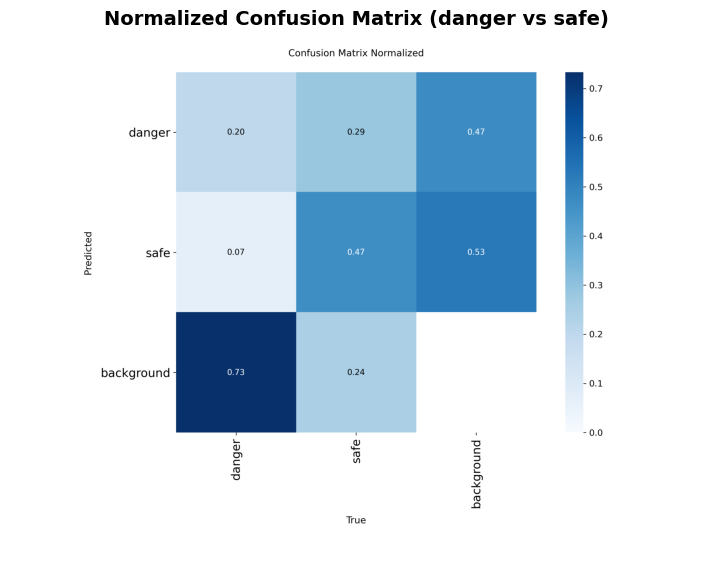

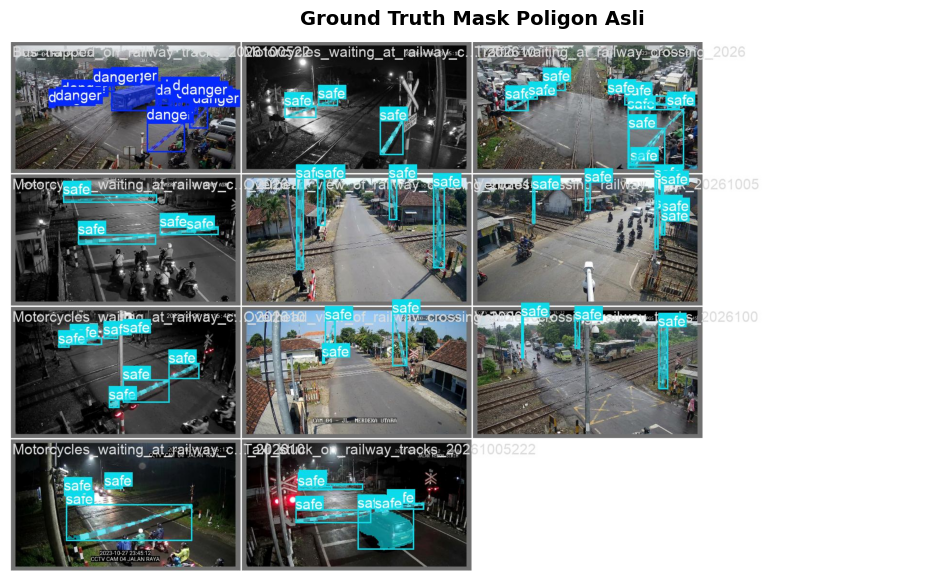

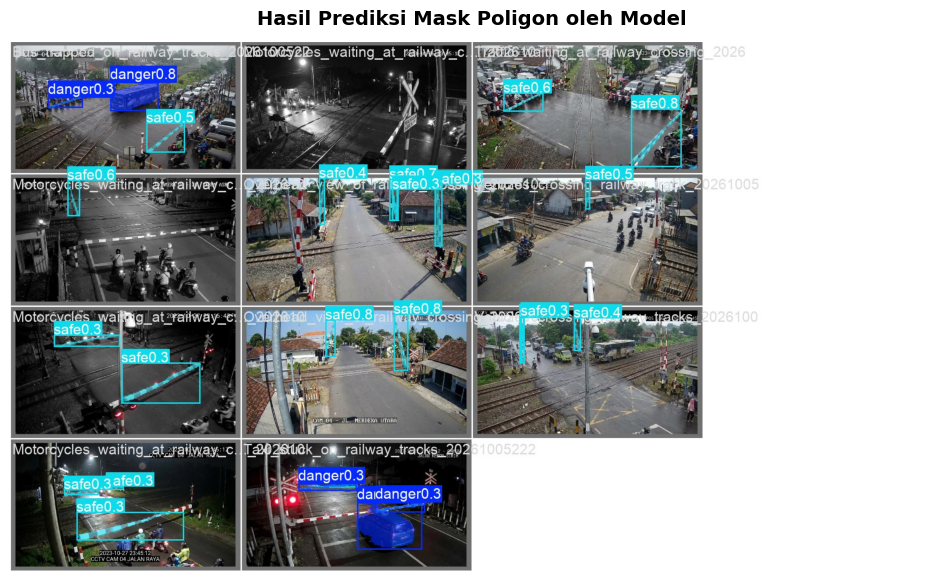

In [4]:
# 4. Visualisasi Hasil Evaluasi Model Segmentasi
import matplotlib.pyplot as plt
from PIL import Image

def show_plot(file_name, title, max_width=12):
    img_path = os.path.join(save_dir, file_name)
    if os.path.exists(img_path):
        img = Image.open(img_path)
        aspect = img.height / img.width
        plt.figure(figsize=(max_width, max_width * aspect))
        plt.imshow(img)
        plt.title(title, fontsize=14, weight='bold', pad=12)
        plt.axis('off')
        plt.show()
    else:
        print(f"File belum tersedia: {file_name}")

# Tampilkan kurva hasil training (loss & mask mAP)
show_plot('results.png', 'Grafik Loss & Metrik Segmentasi (Box mAP & Mask mAP)', max_width=14)

# Tampilkan Confusion Matrix
show_plot('confusion_matrix_normalized.png', 'Normalized Confusion Matrix (danger vs safe)', max_width=9)

# Tampilkan Sampel Prediksi Visual Mask pada Data Validasi
show_plot('val_batch0_labels.jpg', 'Ground Truth Mask Poligon Asli', max_width=12)
show_plot('val_batch0_pred.jpg', 'Hasil Prediksi Mask Poligon oleh Model', max_width=12)

In [5]:
# 5. Salin model terbaik (best.pt) ke root direktori proyek
import shutil

best_weight = os.path.join(save_dir, 'weights', 'best.pt')
destination = 'best.pt'

if os.path.exists(best_weight):
    shutil.copy(best_weight, destination)
    print(f"[SUKSES] Model Segmentasi Terbaik berhasil disimpan di: {os.path.abspath(destination)}")
else:
    print("File best.pt belum ditemukan.")

[SUKSES] Model Segmentasi Terbaik berhasil disimpan di: c:\Users\Pongo\train-detector\best.pt
